In [1]:
import numpy as np
import torch
import pandas as pd
from pycocotools import coco
import matplotlib.pyplot as plt

# Load annoations

In [2]:
coco73annots = np.load('/u/fdammeier/data/NeuroFlow/annots/COCO_73k_annots_curated.npy')
print(coco73annots.shape)
coco73annots[5]

(73000, 5)


array(['A giraffe stands near a tree in the wilderness. ', '', '',
       'Head and neck of a giraffe in natural feeding habitat.',
       'A giraffe walking near a tree with very few leaves.'],
      dtype='<U250')

In [3]:
stim_info = pd.read_pickle("/u/fdammeier/data/NeuroFlow/nsddata/experiments/nsd/nsd_stim_info_merged.pkl")
stim_info.head()

,cocoId,cocoSplit,cropBox,loss,nsdId,flagged,BOLD5000,shared1000,subject1,subject2,...,subject5_rep2,subject6_rep0,subject6_rep1,subject6_rep2,subject7_rep0,subject7_rep1,subject7_rep2,subject8_rep0,subject8_rep1,subject8_rep2
0,532481,val2017,"(0, 0, 0.1671875, 0.1671875)",0.100000,0,False,False,False,0,0,...,0,0,0,0,0,0,0,0,0,0
1,245764,val2017,"(0, 0, 0.125, 0.125)",0.000000,1,False,False,False,0,0,...,0,0,0,0,13985,14176,28603,0,0,0
2,385029,val2017,"(0, 0, 0.125, 0.125)",0.000000,2,False,False,False,0,0,...,0,0,0,0,0,0,0,0,0,0
3,311303,val2017,"(0, 0, 0.16640625, 0.16640625)",0.125000,3,False,False,False,0,0,...,0,0,0,0,0,0,0,0,0,0
4,393226,val2017,"(0, 0, 0.125, 0.125)",0.133333,4,False,False,False,0,0,...,0,13720,22861,23023,0,0,0,0,0,0


In [4]:
import json
with open('/u/fdammeier/data/NeuroFlow/annots/coco/annotations/panoptic_train2017.json', 'r') as f:
    raw = json.load(f)

print(raw.keys())
print(raw["categories"][:5])

dict_keys(['info', 'licenses', 'images', 'annotations', 'categories'])
[{'supercategory': 'person', 'isthing': 1, 'id': 1, 'name': 'person'}, {'supercategory': 'vehicle', 'isthing': 1, 'id': 2, 'name': 'bicycle'}, {'supercategory': 'vehicle', 'isthing': 1, 'id': 3, 'name': 'car'}, {'supercategory': 'vehicle', 'isthing': 1, 'id': 4, 'name': 'motorcycle'}, {'supercategory': 'vehicle', 'isthing': 1, 'id': 5, 'name': 'airplane'}]


# Samples from different latent spaces on test set
## Import saved latents

In [6]:
# Images -> Clip encoder -> Clip features
visual_raw_np  = np.load("/u/fdammeier/data/NeuroFlow/nsd/subj01/nsd_sdxl_clip_test_sub1.npy")
z_clip = torch.from_numpy(visual_raw_np)

# fMRI -> NeuroVAE encoder -> NeuroVAE latents
z_neurovae = torch.load("/u/fdammeier/generations/evals/fm-s1-d12-h13-bs24-v-cos-uni-d1664-zscore-v10-cycle-reverse-proj/sub1/single_s1_all_zfmri.pt")

# NeuroVAE latents -> XFM -> Clip features
z_clip_xfm = torch.load("/u/fdammeier/generations/evals/fm-s1-d12-h13-bs24-v-cos-uni-d1664-zscore-v10-cycle-reverse-proj/sub1/single_s1_all_sample_clip.pt")

# Clip features -> XFM -> NeuroVAE latents
z_neurovae_xfm = torch.load("/u/fdammeier/generations/evals/fm-s1-d12-h13-bs24-v-cos-uni-d1664-zscore-v10-cycle-reverse-proj/sub1/single_s1_all_sample_fmri.pt")

# The latents should all have the same dimension
# N images x T tokens x D token length
z_clip.shape, z_neurovae.shape, z_clip_xfm.shape, z_neurovae_xfm.shape

(torch.Size([1000, 256, 1664]),
 torch.Size([1000, 256, 1664]),
 torch.Size([1000, 256, 1664]),
 torch.Size([1000, 256, 1664]))

# PCA
## Token space

In [7]:
z_clip_tokes = torch.flatten(z_clip, start_dim=0, end_dim=1)
z_neurovae_tokes = torch.flatten(z_neurovae, start_dim=0, end_dim=1)
z_clip_xfm_tokes = torch.flatten(z_clip_xfm, start_dim=0, end_dim=1)
z_neurovae_xfm_tokes = torch.flatten(z_neurovae_xfm, start_dim=0, end_dim=1)
z_clip_tokes.shape

torch.Size([256000, 1664])

In [8]:
def pca(X: torch.Tensor, n_components: int) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    original_dtype = X.dtype
    # SVD is not supported for half-precision on CPU — upcast temporarily
    if X.dtype in (torch.float16, torch.bfloat16):
        X = X.float()

    mean = X.mean(dim=0)
    X_centered = X - mean

    U, S, Vh = torch.linalg.svd(X_centered, full_matrices=False)

    components = Vh[:n_components]
    X_pca = X_centered @ components.T

    variance = (S ** 2) / (len(X) - 1)
    explained_variance_ratio = variance[:n_components] / variance.sum()

    # Cast outputs back to the original dtype
    return X_pca.to(original_dtype), components.to(original_dtype), explained_variance_ratio.to(original_dtype)

In [9]:
pca_clip, components_clip, explained_variance_ratio_clip = pca(z_clip_tokes, n_components=50)

In [12]:
# cumulative explained variance
cumulative_explained_variance_clip = torch.cumsum(explained_variance_ratio_clip, dim=0)
cumulative_explained_variance_clip

tensor([0.0533, 0.0916, 0.1206, 0.1414, 0.1603, 0.1776, 0.1938, 0.2061, 0.2175,
        0.2284, 0.2384, 0.2474, 0.2556, 0.2634, 0.2705, 0.2776, 0.2842, 0.2905,
        0.2964, 0.3018, 0.3069, 0.3120, 0.3169, 0.3218, 0.3262, 0.3308, 0.3350,
        0.3391, 0.3430, 0.3469, 0.3506, 0.3542, 0.3579, 0.3616, 0.3650, 0.3682,
        0.3716, 0.3748, 0.3777, 0.3809, 0.3838, 0.3867, 0.3896, 0.3926, 0.3953,
        0.3979, 0.4006, 0.4033, 0.4060, 0.4087], dtype=torch.float16)

In [54]:
pca_clip.shape

torch.Size([256000, 50])

In [55]:
sum(explained_variance_ratio_clip[:2])

tensor(0.0916, dtype=torch.float16)

In [13]:
rng = np.random.default_rng()

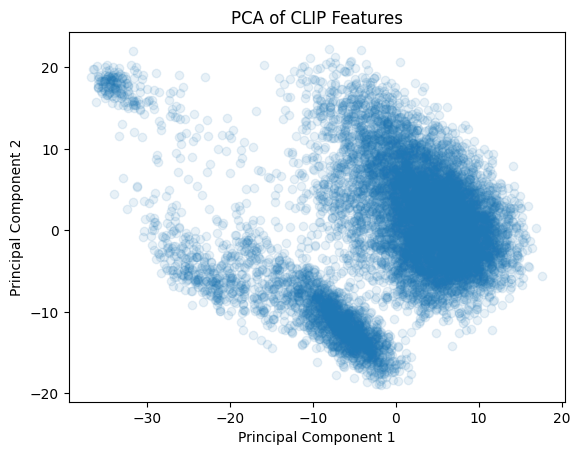

In [ ]:


selection_index = rng.choice(pca_clip.shape[0], size=10000, replace=False)

def plot_pca(pca_result: torch.Tensor, title: str):
    plt.scatter(pca_result[selection_index, 0].numpy(), pca_result[selection_index, 1].numpy(), alpha=0.1)
    plt.title(title)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")

plot_pca(pca_clip, "PCA of CLIP Features")

In [13]:
pca_neurovae, components_neurovae, explained_variance_ratio_neurovae = pca(z_neurovae_tokes, n_components=50)

In [59]:
sum(explained_variance_ratio_neurovae[:2])

tensor(0.1797)

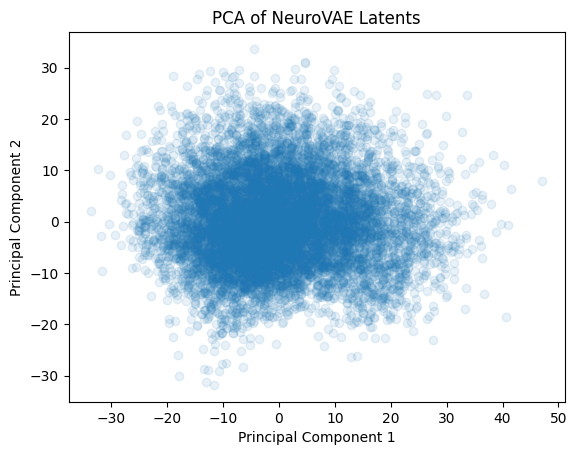

In [60]:
plot_pca(pca_neurovae, "PCA of NeuroVAE Latents")

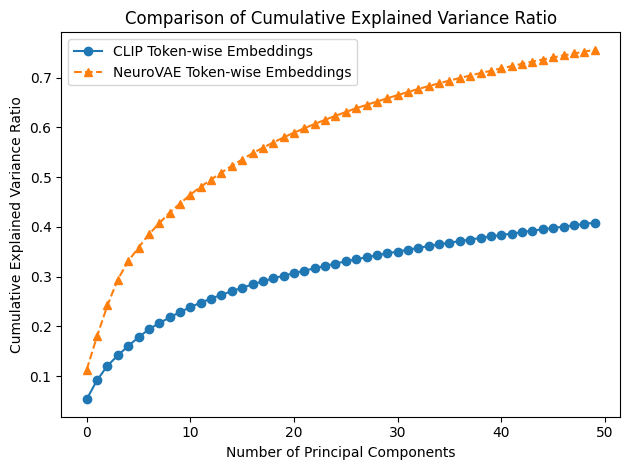

In [19]:
var_clip_cum = np.cumsum(explained_variance_ratio_clip.numpy())
var_neurovae_cum = np.cumsum(explained_variance_ratio_neurovae.numpy())

plt.plot(var_clip_cum, label="CLIP Token-wise Embeddings", marker="o", linestyle="-")
plt.plot(var_neurovae_cum, label="NeuroVAE Token-wise Embeddings", marker="^", linestyle="--")

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.title("Comparison of Cumulative Explained Variance Ratio")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:

pca_clip_xfm, components_clip_xfm, explained_variance_ratio_clip_xfm = pca(z_clip_xfm_tokes, n_components=50)

In [62]:
sum(explained_variance_ratio_clip_xfm[:2])

tensor(0.1181)

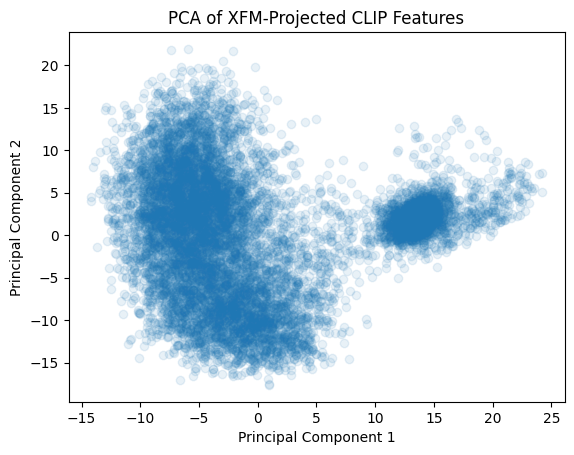

In [63]:
plot_pca(pca_clip_xfm, "PCA of XFM-Projected CLIP Features")

In [21]:
pca_neurovae_xfm, components_neurovae_xfm, explained_variance_ratio_neurovae_xfm = pca(z_neurovae_xfm_tokes, n_components=50)

In [65]:
sum(explained_variance_ratio_neurovae_xfm[:2])

tensor(0.1165)

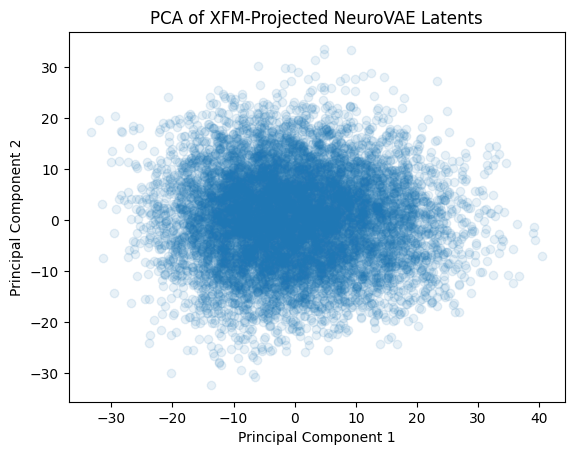

In [66]:
plot_pca(pca_neurovae_xfm, "PCA of XFM-Projected NeuroVAE Latents")

# UMAP

In [22]:
import umap
from sklearn.preprocessing import StandardScaler

reducer = umap.UMAP()

z_clip_umap = reducer.fit_transform(StandardScaler().fit_transform(pca_clip))

/u/fdammeier/repositories/NeuroFlow/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def plot_umap(umap_result: np.ndarray, title: str):
    plt.scatter(umap_result[selection_index, 0], umap_result[selection_index, 1], alpha=0.1)
    plt.title(title)
    plt.xlabel("UMAP Dimension 1")
    plt.ylabel("UMAP Dimension 2")

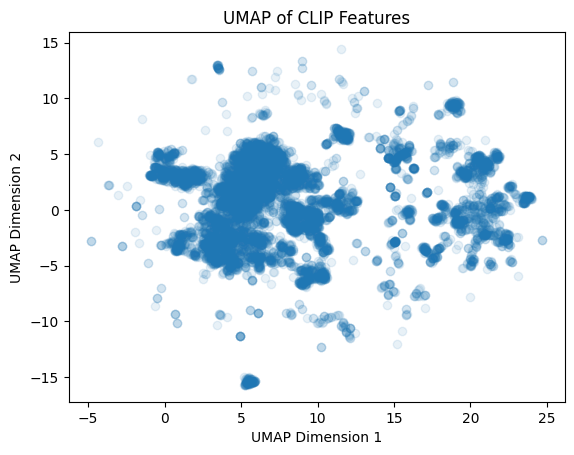

In [ ]:
plot_umap(z_clip_umap, "UMAP of CLIP Features")

In [ ]:
z_neurovae_umap = reducer.fit_transform(StandardScaler().fit_transform(pca_neurovae))

In [ ]:
plot_umap(z_neurovae_umap, "UMAP of NeuroVAE Latents")

# Representational similarity analysis (RSA)

In [10]:
from scipy.spatial.distance import squareform, pdist
import matplotlib.pyplot as plt
import skdim

In [11]:
z_clip_flattened = z_clip.flatten(start_dim=1, end_dim=2)
z_clip_flattened.shape

torch.Size([1000, 425984])

In [ ]:
z_clip_pdist = pdist(z_clip_flattened.numpy(), 'correlation')

In [ ]:
z_clip_dmat = squareform(z_clip_pdist)

In [ ]:
def compute_representational_dissimilarity_matrix(X: torch.Tensor, metric: str = 'correlation') -> np.ndarray:
    X = X.numpy()
    pdist_result = pdist(X, metric)
    dmat = squareform(pdist_result)
    return dmat
    

In [ ]:
def visualize_and_save_dmat(X: torch.Tensor, metric: str = 'correlation', save_path: str = None, ds_name: str = "ds", verbose: bool = False):
    dmat = compute_representational_dissimilarity_matrix(X, metric)
    
    plt.figure(figsize=(8, 6))
    plt.imshow(dmat, cmap='viridis')
    plt.colorbar()
    plt.title(f'{ds_name} - RDM ({metric})')
    plt.xlabel('Samples')
    plt.ylabel('Samples')
    plt.tight_layout()
    
    if save_path:
        save_path = f"{save_path}/{ds_name}_{metric}_rdm.png"
        plt.savefig(save_path)
        if verbose:
            print(f"RDM saved to {save_path}")
    if verbose:
        plt.show()

In [ ]:
z_clip_dmat = compute_representational_dissimilarity_matrix(z_clip_flattened)
z_neurvae_dmat = compute_representational_dissimilarity_matrix(z_neurovae.flatten(start_dim=1, end_dim=2))
clip_xfm_dmat = compute_representational_dissimilarity_matrix(z_clip_xfm.flatten(start_dim=1, end_dim=2))
neurovae_xfm_dmat = compute_representational_dissimilarity_matrix(z_neurovae_xfm.flatten(start_dim=1, end_dim=2))

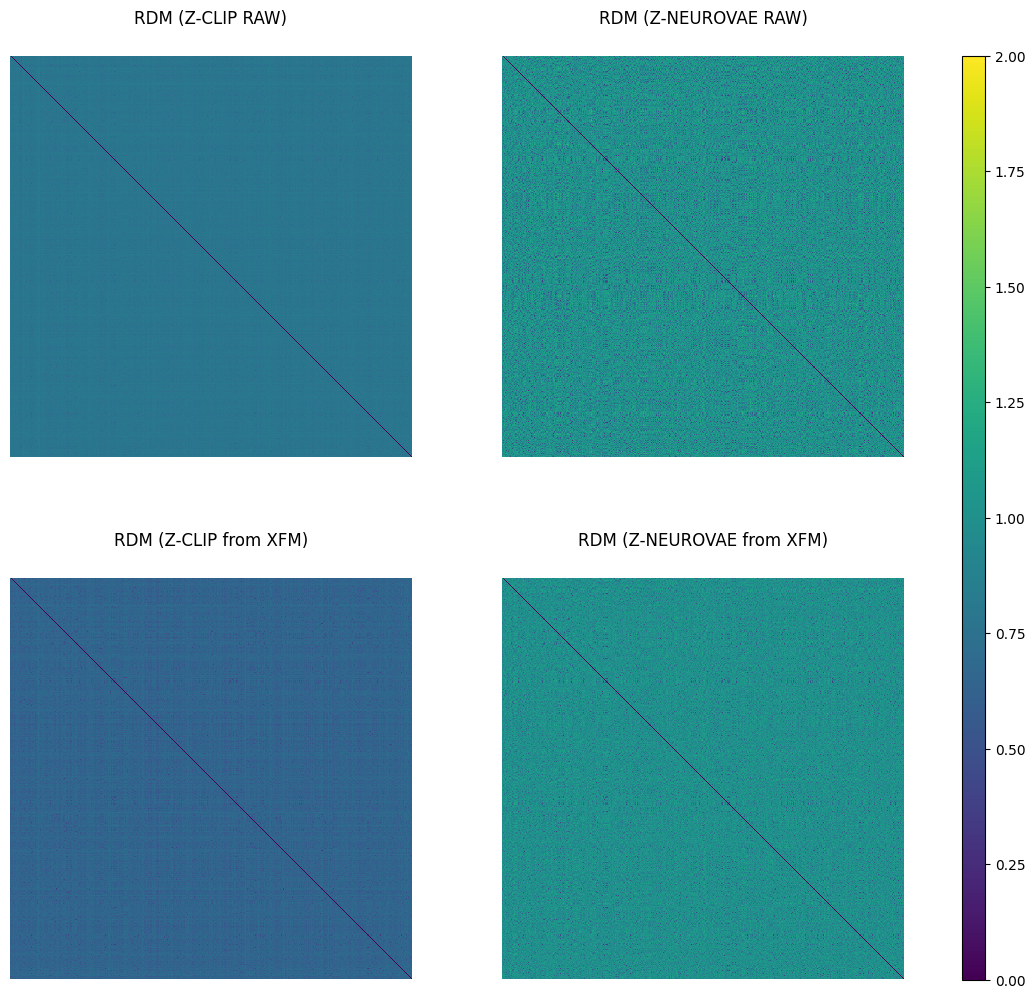

In [ ]:
import matplotlib.gridspec as gridspec

matrices = [z_clip_dmat, z_neurvae_dmat, clip_xfm_dmat, neurovae_xfm_dmat]
titles = ["RDM (Z-CLIP RAW)", "RDM (Z-NEUROVAE RAW)", "RDM (Z-CLIP from XFM)", "RDM (Z-NEUROVAE from XFM)"]
 
fig = plt.figure(figsize=(13, 12))
 
# GridSpec: 2 rows × 2 cols for plots, plus a narrow column for the colorbar
gs = gridspec.GridSpec(
    2, 3,
    width_ratios=[1, 1, 0.05],   # last column is the colorbar
    hspace=0.3,
    wspace=0.08,
)
 
vmin, vmax, cmap = 0, 2, "viridis"
im = None
 
for idx, (mat, title) in enumerate(zip(matrices, titles)):
    row, col = divmod(idx, 2)
    ax = fig.add_subplot(gs[row, col])
    im = ax.matshow(mat, vmin=vmin, vmax=vmax, cmap=cmap)
    ax.set_title(title, fontsize=12)
    ax.axis("off")                # hide ticks and labels entirely
 
# Single shared colorbar in the dedicated right column
cbar_ax = fig.add_subplot(gs[:, 2])   # spans both rows
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.ax.tick_params(labelsize=10)
 
plt.savefig("rdmatrices_2x2.png", dpi=150, bbox_inches="tight")
plt.show()


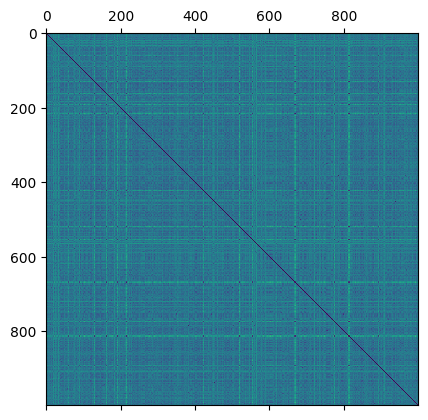

In [ ]:
first_token_clip_dmap = compute_representational_dissimilarity_matrix(z_clip[:, 3, :])
plt.matshow(first_token_clip_dmap, vmax=2, vmin=0, cmap='viridis')

# Intrinsic dimensionality

In [17]:
import skdim

## On flattened vectors (one for each image)

In [16]:
datasets = [z_clip, z_neurovae, z_clip_xfm, z_neurovae_xfm]
labels = ["CLIP Image Embeddings", "NeuroVAE Embeddings", "NeuroVAE Embeddings to CLIP via XFM", "CLIP Embeddings to NeuroVAE via XFM"]

In [ ]:
print("Estimating Intrinsic Dimensionality using TwoNN method:")
for dataset, label in zip(datasets, labels):
    twoNN = skdim.id.TwoNN()
    d = twoNN.fit_transform(dataset.flatten(start_dim=1, end_dim=2))
    print(f"{label}: Estimated Intrinsic Dimensionality = {d:.2f}")

Estimating Intrinsic Dimensionality using TwoNN method:
CLIP Image Embeddings: Estimated Intrinsic Dimensionality = 101.57
NeuroVAE Embeddings: Estimated Intrinsic Dimensionality = 20.88
NeuroVAE Embeddings to CLIP via XFM: Estimated Intrinsic Dimensionality = 33.29
CLIP Embeddings to NeuroVAE via XFM: Estimated Intrinsic Dimensionality = 27.67


## On token space 

In [17]:
rng = np.random.default_rng(99)
subsample_idx = rng.choice(1000*256, size=20000, replace=False)

print("Estimating Intrinsic Dimensionality using TwoNN method:")
for dataset, label in zip(datasets, labels):
    twoNN = skdim.id.TwoNN()
    d = twoNN.fit_transform(dataset.flatten(start_dim=0, end_dim=1)[subsample_idx])
    print(f"{label}: Estimated Intrinsic Dimensionality = {d:.2f}")

Estimating Intrinsic Dimensionality using TwoNN method:
CLIP Image Embeddings: Estimated Intrinsic Dimensionality = 6.14
NeuroVAE Embeddings: Estimated Intrinsic Dimensionality = 2.95
NeuroVAE Embeddings to CLIP via XFM: Estimated Intrinsic Dimensionality = 3.54
CLIP Embeddings to NeuroVAE via XFM: Estimated Intrinsic Dimensionality = 7.98


## On individual tokens (256 for each image)

In [20]:
datasets[0][:, 1].shape

torch.Size([1000, 1664])

Estimating Intrinsic Dimensionality using TwoNN method:


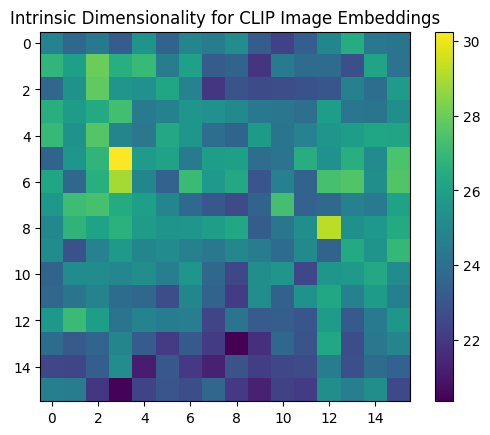

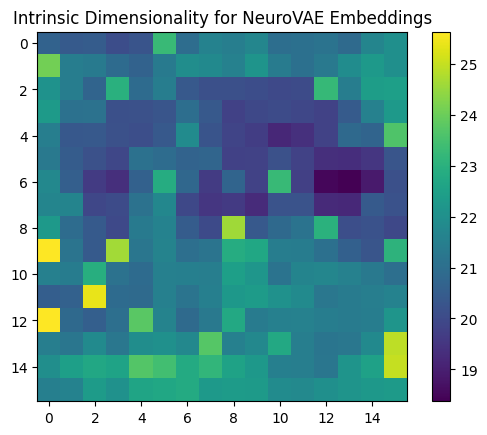

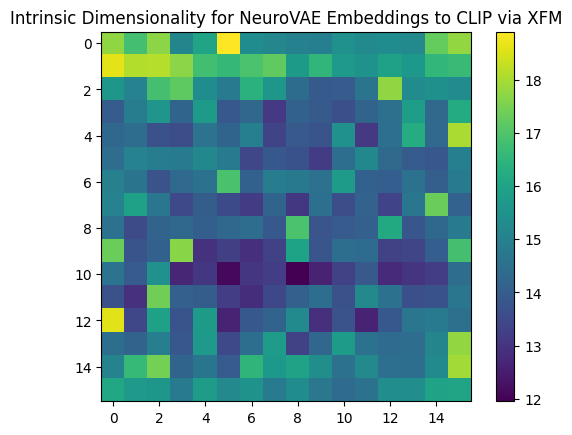

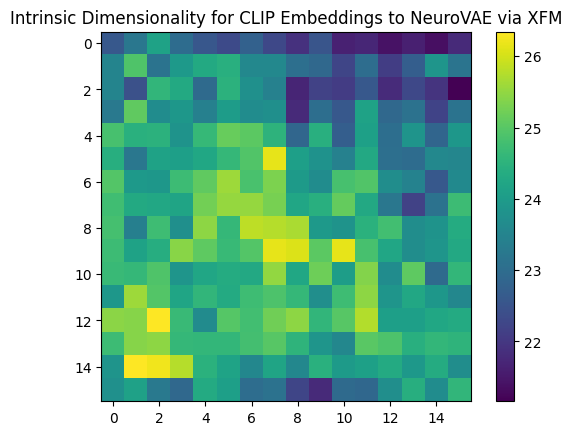

In [ ]:
print("Estimating Intrinsic Dimensionality using TwoNN method:")
for dataset, label in zip(datasets, labels):
    intrinsic_dims = []
    for token in range(dataset.shape[1]):
        twoNN = skdim.id.TwoNN()
        d = twoNN.fit_transform(dataset[:, token])
        intrinsic_dims.append(d)
    # reshape to positional grid
    intrinsic_dims_grid = np.array(intrinsic_dims).reshape(16, 16)
    plt.imshow(intrinsic_dims_grid, cmap='viridis')
    plt.title(f"Token ID - {label}")
    plt.colorbar()
    plt.show()

## Using different distance metrics

In [ ]:
D = z_clip_dmat

np.fill_diagonal(D, np.inf)      # exclude self-distance
D_sorted = np.sort(D, axis=1)    # sort each row ascending

r1 = D_sorted[:, 0]              # nearest neighbor distance
r2 = D_sorted[:, 1]              # second-nearest neighbor distance

X_dist = np.column_stack([r1, r2])   # shape (N, 2)

twonn = skdim.id.TwoNN(dist=True)
twonn.fit(X_dist)

dim = twonn.dimension_
dim